# 📊Topic - Telecom Customer Churn #

In today’s fast-paced telecom sector, customer retention plays a vital role in sustaining profitability and competitive advantage. To better understand churn behavior, the company has compiled a comprehensive dataset capturing customer demographics, service subscriptions, billing preferences, and usage history. The primary objective is to build a predictive model that can accurately identify which customers are at risk of leaving the service, enabling proactive engagement and retention strategies.



# 📊Key Features
The dataset captures a rich snapshot of customer behavior and service engagement, structured across four key dimensions:
- Churn Status: Indicates whether a customer has discontinued service within the past month, flagged in the Churn column.
- Service Subscriptions: Details the specific services each customer uses, including phone service, multiple lines, internet access, online security     , backup solutions, device protection, technical support, and streaming platforms for TV and movies.
- Account Attributes: Includes tenure, contract type, billing preferences (e.g., paperless billing), payment method, monthly charg and
  total charges—  offering insight into customer value and billing patterns.
- Demographics: Provides personal context such as gender, age group, and household status (presence of partners or dependents), which may
  influence churn behaviour

### Importing Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
churn=pd.read_csv("Telcom Data.csv")
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
churn.duplicated().sum()

np.int64(0)

In [5]:
churn.isnull().sum().sum()

np.int64(0)

### Observation:- All features have 7043 enteries , it means there is no null value

In [6]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### To check uniques values in each feature

In [7]:
for i in churn.columns:
    print(i)
    print()
    print(set(churn[i].tolist()))
    print("****************************************************************************************************************************")
    print()

customerID

{'4291-TPNFG', '0244-LGNFY', '0576-WNXXC', '4210-QFJMF', '4801-KFYKL', '1379-FRVEB', '2587-EKXTS', '2040-OBMLJ', '6253-GNHWH', '0787-LHDYT', '6954-OOYZZ', '6024-RUGGH', '2433-KMEAS', '7520-HQWJU', '9385-EHGDO', '2990-IAJSV', '9766-HGEDE', '2212-LYASK', '4803-AXVYP', '0839-QNXME', '6898-MDLZW', '0397-ZXWQF', '2519-LBNQL', '3916-NRPAP', '8884-FEEWR', '6766-HFKLA', '0875-CABNR', '3658-KIBGF', '7596-IIWYC', '9891-NQDBD', '3030-YDNRM', '2634-HCZGT', '1839-FBNFR', '4568-TTZRT', '3120-FAZKD', '1320-HTRDR', '6086-ESGRL', '9488-FYQAU', '0512-FLFDW', '3566-CAAYU', '2209-XADXF', '8761-NSOBC', '0225-ZORZP', '9546-CQJSU', '6646-VRFOL', '0769-MURVM', '4109-CYRBD', '7136-IHZJA', '0795-XCCTE', '7993-PYKOF', '7017-VFULY', '6248-TKCQV', '4531-AUZNK', '4923-ADWXJ', '6661-HBGWL', '0953-LGOVU', '4211-MMAZN', '5567-GZKQY', '0310-SUCIN', '5542-DHSXL', '6993-YGFJV', '1143-NMNQJ', '5149-QYTTU', '3733-ZEECP', '8143-ETQTI', '7369-TRPFD', '3334-CTHOL', '7598-UAASY', '7138-GIRSH', '7858-GTZSP', '4763-P

### To count the number of people in one type of category

In [8]:
for i in churn.columns:
    print(i)
    print()
    print(churn[i].value_counts(normalize=True))
    print('*********************************************************************************************************************')
    print()

customerID

customerID
7590-VHVEG    0.000142
5575-GNVDE    0.000142
3668-QPYBK    0.000142
7795-CFOCW    0.000142
9237-HQITU    0.000142
                ...   
6840-RESVB    0.000142
2234-XADUH    0.000142
4801-JZAZL    0.000142
8361-LTMKD    0.000142
3186-AJIEK    0.000142
Name: proportion, Length: 7043, dtype: float64
*********************************************************************************************************************

gender

gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64
*********************************************************************************************************************

SeniorCitizen

SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64
*********************************************************************************************************************

Partner

Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64
**************************************************************

### Checking skewness of int/float datatype

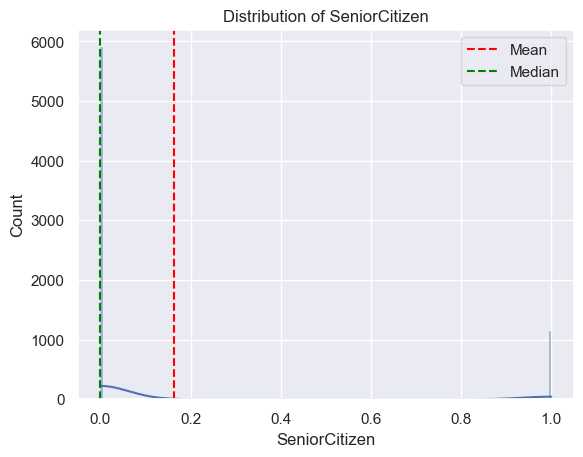

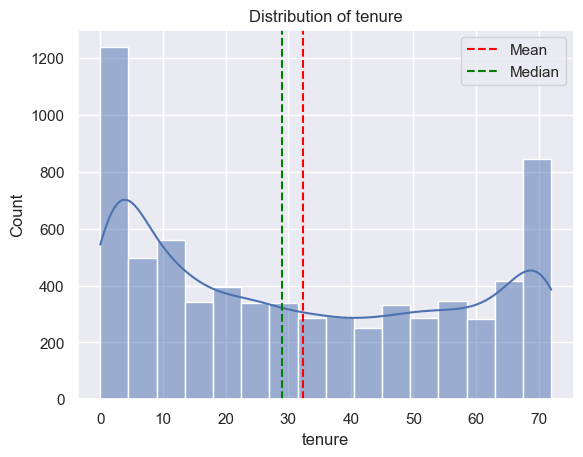

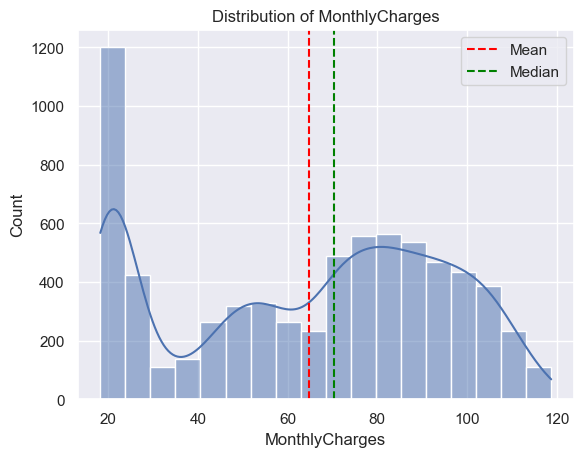

In [9]:
def distplot(cols):
    sns.histplot(churn[cols], kde=True)
    plt.axvline(churn[cols].mean(),   color='red',   linestyle='--', label='Mean')
    plt.axvline(churn[cols].median(), color='green', linestyle='--', label='Median')
    plt.title(f'Distribution of {cols}')
    plt.legend()
    plt.show()

for i in churn.select_dtypes(exclude=['object']).columns:
    distplot(i)

# Heatmap for correlation

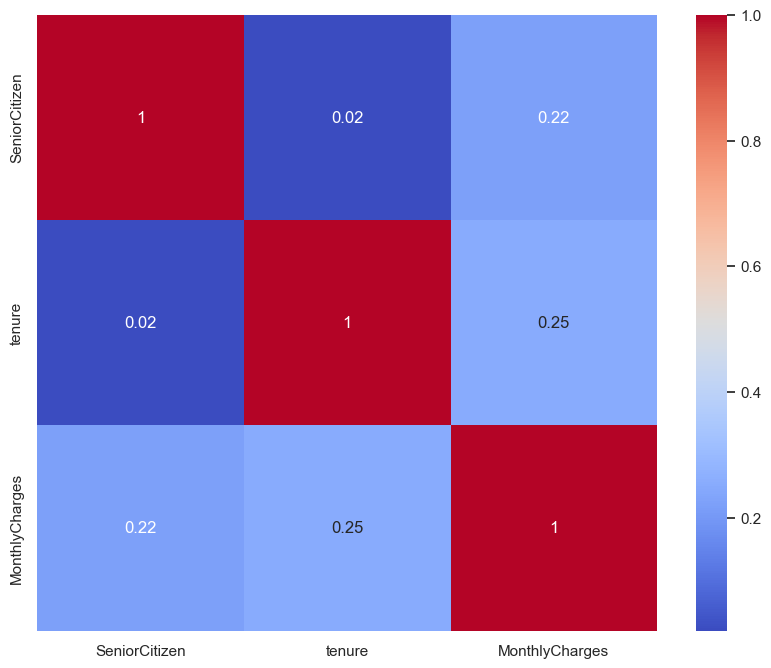

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(churn.select_dtypes(exclude=['object']).corr().round(2),annot=True,cmap='coolwarm')
plt.show()

### Observations
- tenure and TotalCharges are positively correlated :
  longer tenure = higher total charges (expected).
- MonthlyCharges and TotalCharges are also correlated.
- No multicollinearity treatment needed :
  tree-based models handle correlated features natively.

### Visualizations

<Axes: xlabel='Churn', ylabel='tenure'>

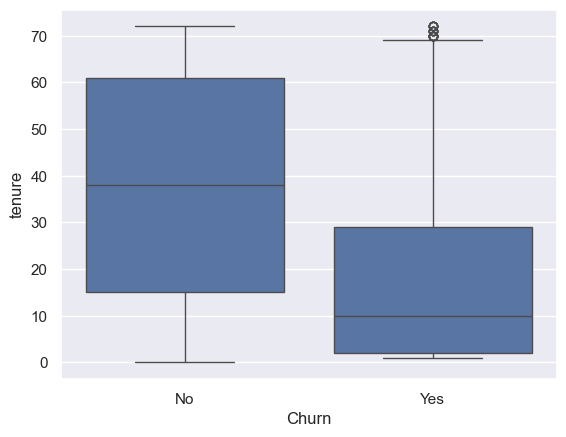

In [11]:
sns.boxplot(y=churn['tenure'],x=churn['Churn'])

### Observations :- - Customers who didn't churn have a median tenure around 40 months, while those who did churn hover around 10 months.

<Axes: xlabel='count', ylabel='PaymentMethod'>

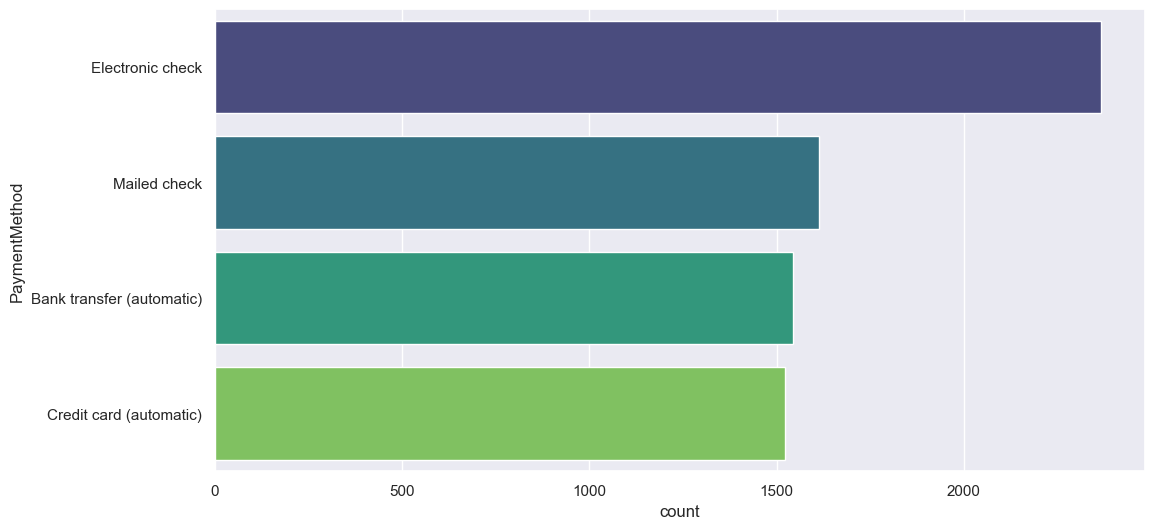

In [12]:
f,ax = plt.subplots(figsize=(12,6))
sns.countplot(churn['PaymentMethod'] , palette='viridis')

### Observations:- Mostly customers Paid their bills through Electronic check followed by mailed check.
### Customers paying through Bank Transfer and Credit card are almost same.

<Axes: xlabel='count', ylabel='Churn'>

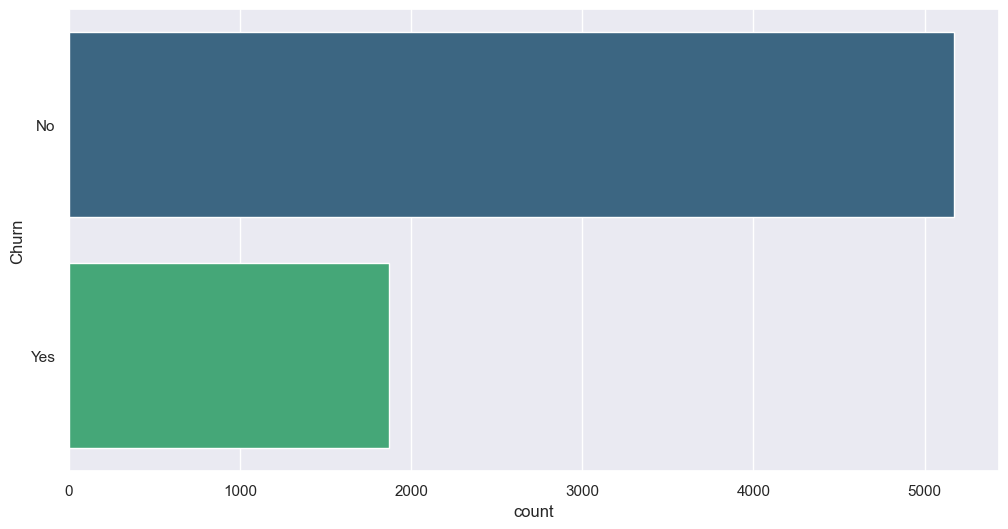

In [13]:
f,ax = plt.subplots(figsize=(12,6))
sns.countplot(churn['Churn'] , palette='viridis')

### Observations:- Most of the customers are not leaving the services provided by the company wheras almost 1800 customers are leaving due to certain factors such as High charges , no proper service , etc.


26.536987079369588


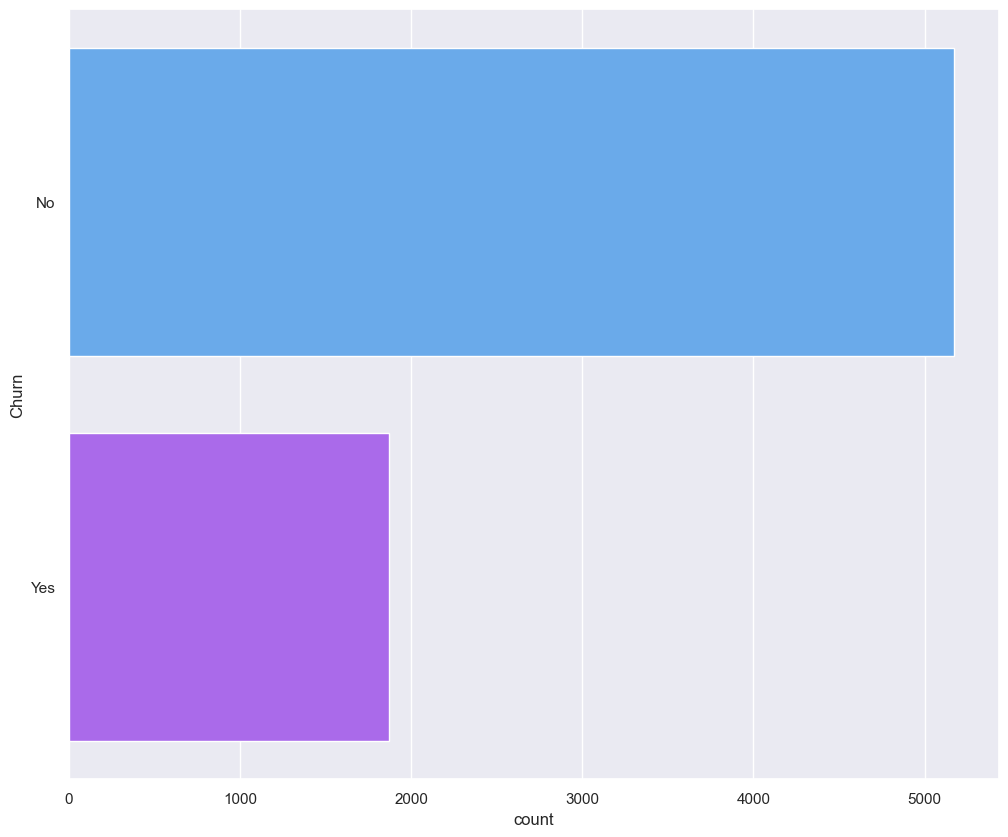

In [14]:
fig,ax1 = plt.subplots(figsize=(12,10))
sns.countplot(churn['Churn'] , palette='cool')
print(len(churn[churn['Churn']=='Yes'])/len(churn)*100)

#### Observations:-
##### 27% Customers are likely to Churn

<Axes: xlabel='gender', ylabel='count'>

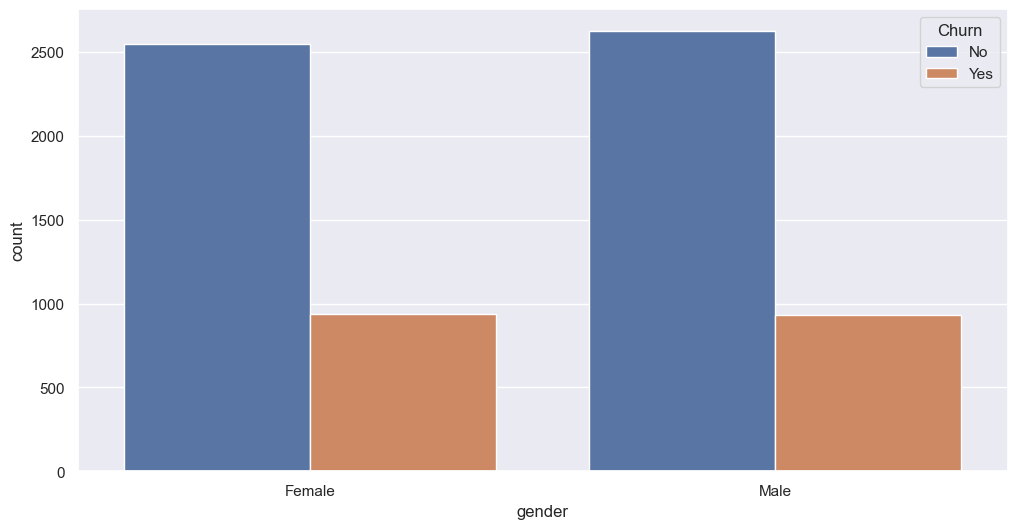

In [15]:
fig,ax1 = plt.subplots(figsize=(12,6))
sns.countplot(x='gender',data=churn,hue='Churn')

# Observations:-
#### Almost same number of customers of Male and Female gender are likley to churn.
#### This shows that churning of customers is not Gender bias.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

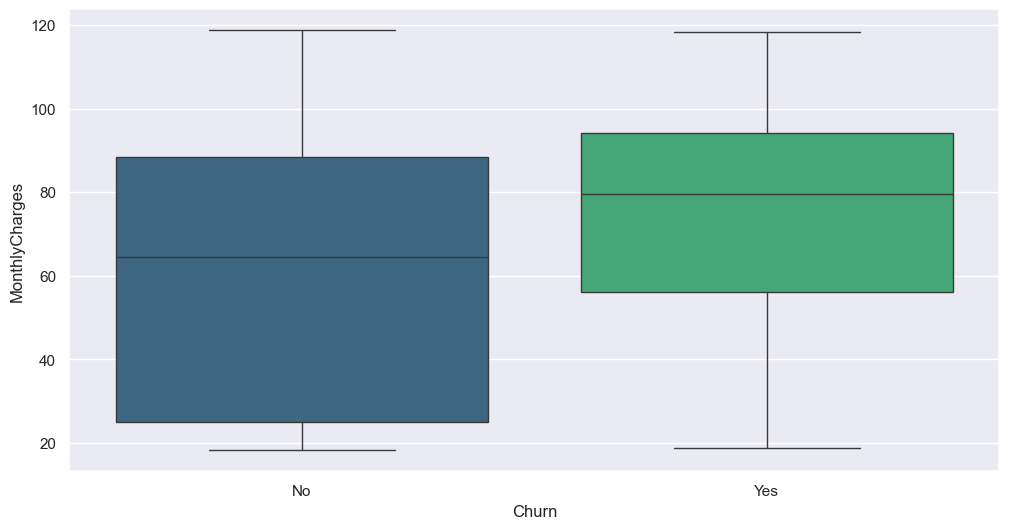

In [16]:
fig,ax1 = plt.subplots(figsize=(12,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn , palette='viridis')

# Observations:
#### The customers likely to churn are paying more monthly charges , no doubt, they will leave

# Buisness Analysis
##### 1.) Customers are paying more monthly bill and so are leaving the company. Providing them with some benefits such as free subscription , High internet speed , Loyalty points , etc.
##### 2.) Mostly Customers are young , to attract more young people , company should provide regular offers , gamified environment rewards and free usage of musing or movies app.
##### 3.) Promote long-term contracts with bundled perks , eg., Offer tenure based rewards
##### 4.) Special offers on special occasions should be provided such as 50%off on charges+free OTT subscription.

In [17]:
churn['Churn']=churn['Churn'].replace({'Yes':1 , 'No':0})

New customers with 0 tenure have blank TotalCharges

In [18]:
churn['TotalCharges']=churn['TotalCharges'].replace(" ",np.nan)

In [19]:
churn['TotalCharges'].isnull().sum()

np.int64(11)

In [20]:
churn['TotalCharges'].dtype

dtype('O')

In [21]:
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'])

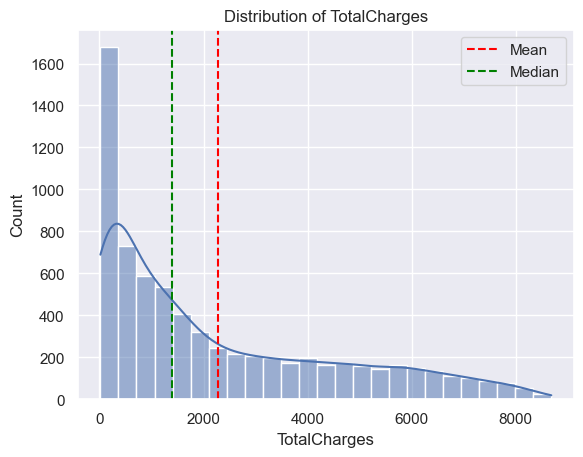

In [22]:
sns.histplot(churn['TotalCharges'], kde=True)
plt.axvline(churn['TotalCharges'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(churn['TotalCharges'].median(), color='green', linestyle='--', label='Median')
plt.legend()
plt.title("Distribution of TotalCharges")
plt.show()

In [23]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [24]:
churn['TotalCharges'].isnull().sum()

np.int64(11)

In [25]:
churn['TotalCharges']=churn['TotalCharges'].fillna(churn['TotalCharges'].median())

In [26]:
churn.isnull().sum().sum()

np.int64(0)

In [27]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [28]:
churn=churn.drop('customerID' , axis=1)

# Using one hot encoder

In [29]:
churn_encoder=pd.get_dummies(churn , columns=['Dependents','gender', 'Partner',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],drop_first=True)

In [30]:
churn_encoder.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Dependents_Yes,gender_Male,Partner_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,True,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,True,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,True,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [31]:
churn_bool=churn_encoder.map(lambda x:int(x) if isinstance(x,bool) else x)

In [32]:
churn_bool.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Dependents_Yes,gender_Male,Partner_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,0,1,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,0,1,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [33]:
churn_bool.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   Dependents_Yes                         7043 non-null   int64  
 6   gender_Male                            7043 non-null   int64  
 7   Partner_Yes                            7043 non-null   int64  
 8   PhoneService_Yes                       7043 non-null   int64  
 9   MultipleLines_No phone service         7043 non-null   int64  
 10  MultipleLines_Yes                      7043 non-null   int64  
 11  Inte

In [34]:
churn_bool.to_csv("churn for BI.csv", index=False)

# Splitting into independent and dependent datasets

In [35]:
x=churn_bool.drop('Churn' , axis=1)
y=churn_bool['Churn']

In [36]:
x.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Dependents_Yes,gender_Male,Partner_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [37]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

# Building the model

In [38]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test=train_test_split(x , y , test_size=0.2 , random_state=42)

In [39]:
# %pip install imblearn

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

x_train[scaler_columns] = scaler.fit_transform(x_train[scaler_columns])
x_test[scaler_columns] = scaler.transform(x_test[scaler_columns])

In [42]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

# Importing all the models and metrics

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix , classification_report , accuracy_score, f1_score, roc_auc_score,recall_score

In [44]:
logit = LogisticRegression(max_iter=1000)
dtree = DecisionTreeClassifier(random_state=42)
rforest = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
gnb = GaussianNB()
svc = SVC(probability=True, class_weight='balanced', random_state=42)

In [45]:
logit.fit(x_train_res, y_train_res)
dtree.fit(x_train_res, y_train_res)
rforest.fit(x_train_res, y_train_res)
knn.fit(x_train_res, y_train_res)
xgb.fit(x_train_res, y_train_res)
gnb.fit(x_train_res, y_train_res)
svc.fit(x_train_res, y_train_res)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [46]:
voting = VotingClassifier(
    estimators=[
        ('lr', logit),
        ('dt', dtree),
        ('rf', rforest),
        ('knn', knn),
        ('xgb', xgb),
        ('gnb', gnb),
        ('svc', svc)
    ],
    voting='soft'
)

voting.fit(x_train_res, y_train_res)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dt', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [47]:
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:
        y_prob = y_pred  # fallback for simple models

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    recall = recall_score(y_test, y_pred)

    return acc, f1, roc, recall

In [48]:

models = {
    "LogisticRegression": logit,
    "DecisionTree": dtree,
    "RandomForest": rforest,
    "KNN": knn,
    "XGBoost": xgb,
    "GaussianNB": gnb,
    "SVC": svc,
    "VotingClassifier": voting
}

results = []

for name, model in models.items():
    acc, f1, roc, recall = evaluate_model(model, x_test, y_test)
    results.append([name, acc, f1, roc, recall])

df_results = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "F1 Score", "ROC AUC", "Recall"
])

df_results = df_results.sort_values(by="F1 Score", ascending=False)
print(df_results)

                Model  Accuracy  F1 Score   ROC AUC    Recall
0  LogisticRegression  0.767921  0.640264  0.851420  0.780161
6                 SVC  0.767211  0.630631  0.841100  0.750670
7    VotingClassifier  0.756565  0.622662  0.845212  0.758713
4             XGBoost  0.767211  0.600000  0.826708  0.659517
2        RandomForest  0.773598  0.598742  0.832992  0.638070
5          GaussianNB  0.684883  0.594891  0.836307  0.873995
3                 KNN  0.710433  0.574113  0.789957  0.737265
1        DecisionTree  0.726047  0.521092  0.674507  0.563003


In [49]:
y_prob = logit.predict_proba(x_test)[:, 1]

y_pred_new = (y_prob >= 0.3).astype(int)

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.95      0.61      0.74      1036
           1       0.46      0.92      0.61       373

    accuracy                           0.69      1409
   macro avg       0.71      0.76      0.68      1409
weighted avg       0.82      0.69      0.71      1409



The model prioritizes recall over precision for churn class, ensuring most potential churn customers are correctly identified, which is critical for retention-focused business use cases.

In [50]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": logit.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(importance.head(10))

                                 Feature  Coefficient
2                         MonthlyCharges     7.192539
8         MultipleLines_No phone service     1.731903
3                           TotalCharges     1.071548
11                    InternetService_No     0.750858
12    OnlineSecurity_No internet service     0.750858
14      OnlineBackup_No internet service     0.750858
18       TechSupport_No internet service     0.750858
20       StreamingTV_No internet service     0.750858
16  DeviceProtection_No internet service     0.750858
22   StreamingMovies_No internet service     0.750858


In [51]:
from joblib import dump

dump(logit, "model_logit.joblib")


dump(scaler, "scaler.joblib")


dump(list(x.columns), "feature_list.joblib")

['feature_list.joblib']